# Tune EC parameters using all of the formation data
Andrew Weng

In [ ]:
import os, sys

# Move the path up a level to be able to index into source files
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('../')
    sys.path.insert(0, 'src/')

from src import cellsim as cellsim

from scipy.interpolate import interp1d

import pickle
import numpy as np
from matplotlib import pyplot as plt
from src import plotter as plotter
from src import ioutils as ioutils 
from src import simutils as simutils

%load_ext autoreload
%matplotlib widget

plotter.initialize(plt)

# Load the experimental data

In [2]:
# Load the experimental data
expt1, _ = ioutils.fetch_experimental_data(152064, 400)
expt2, _ = ioutils.fetch_experimental_data(152074, 400)
expt3, _ = ioutils.fetch_experimental_data(152071, 400)
expt4, _ = ioutils.fetch_experimental_data(152098, 400)


dt_data_interp = 5.0
t_interp1, i_interp1 = simutils.interpolate_raw_data(expt1['arbin_time'], expt1['arbin_current'], dt_data_interp)
t_interp2, i_interp2 = simutils.interpolate_raw_data(expt2['arbin_time'], expt2['arbin_current'], dt_data_interp)
t_interp3, i_interp3 = simutils.interpolate_raw_data(expt3['arbin_time'], expt3['arbin_current'], dt_data_interp)
t_interp4, i_interp4 = simutils.interpolate_raw_data(expt4['arbin_time'], expt4['arbin_current'], dt_data_interp)


In [3]:
# Define affected regions for each dataset
# Format: (expt, label, t_start, t_end)
kink_regions = [
    (expt1, 'Base 1', 0.5, 0.75),
    (expt2, 'Base 2', 0.5, 0.85),
    (expt3, 'Fast', 0.5, 0.6),
    (expt4, 'Fast+', 0.5, 0.55),
]

# Apply smoothing to each dataset
smoothed_strains = {}
for expt, label, t_start, t_end in kink_regions:
    daq_time = np.array(expt['daq_time'])
    daq_strain = np.array(expt['daq_strain'])
    
    # Convert to hours from zero
    daq_time_hours = (daq_time - daq_time[0]) / 3600.0
    
    # Apply smoothing
    strain_smoothed = ioutils.smooth_kink_region(daq_time_hours, daq_strain, t_start, t_end)
    smoothed_strains[label] = {
        'time_hours': daq_time_hours,
        'original': daq_strain,
        'smoothed': strain_smoothed,
        't_start': t_start,
        't_end': t_end
    }

expt1['daq_strain_smoothed'] = smoothed_strains['Base 1']['smoothed']
expt2['daq_strain_smoothed'] = smoothed_strains['Base 2']['smoothed']
expt3['daq_strain_smoothed'] = smoothed_strains['Fast']['smoothed']
expt4['daq_strain_smoothed'] = smoothed_strains['Fast+']['smoothed']
    

# Set diffusivities

In [ ]:
nn = 35

diff_ec_vec = np.logspace(-22, -17, nn)
diff_vc_vec = np.logspace(-21, -12, nn+1)

rmse1_e_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))
rmse1_v_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))
rmse2_e_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))
rmse2_v_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))
rmse3_e_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))
rmse3_v_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))
qsei1_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))
qsei2_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))
qsei3_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))
qsei1_vc_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))
qsei2_vc_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))
qsei3_vc_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))

expan1_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))
expan2_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))
expan3_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))

resistance1_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))
resistance2_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))   
resistance3_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))

count = 1

for i, diff_ec in enumerate(diff_ec_vec):
    for j, diff_vc in enumerate(diff_vc_vec):

        print(f'Running D_EC = {diff_ec:.2e} m2/s and D_VC = {diff_vc:.2e} m2/s ({count} of {nn*(nn+1)})')
        count += 1

        try:
            df_sim1 = simutils.run_sim('base', diff_ec, diff_vc, dt=1, include_flag=3)
            df_sim2 = simutils.run_sim('fast', diff_ec, diff_vc, dt=1, include_flag=3)
            df_sim3 = simutils.run_sim('fast+', diff_ec, diff_vc, dt=1, include_flag=3)
        except:
            print('ERROR')
            continue

        # Extract the qsei values:
        qsei1_mat[i, j] = df_sim1['q_sei'].iloc[-1]
        qsei2_mat[i, j] = df_sim2['q_sei'].iloc[-1]
        qsei3_mat[i, j] = df_sim3['q_sei'].iloc[-1]

        qsei1_vc_mat[i, j] = df_sim1['q_sei2'].iloc[-1]
        qsei2_vc_mat[i, j] = df_sim2['q_sei2'].iloc[-1]
        qsei3_vc_mat[i, j] = df_sim3['q_sei2'].iloc[-1]

        # Extract the expansion values:
        expan1_mat[i, j] = df_sim1['expansion'].iloc[-1]
        expan2_mat[i, j] = df_sim2['expansion'].iloc[-1]
        expan3_mat[i, j] = df_sim3['expansion'].iloc[-1]

        # Extract the resistance values:
        resistance1_mat[i, j] = df_sim1['R_sei'].iloc[-1]
        resistance2_mat[i, j] = df_sim2['R_sei'].iloc[-1]
        resistance3_mat[i, j] = df_sim3['R_sei'].iloc[-1]

        # Beware of experimental vs model data indexing!!
        rmse1_v, _, _ = simutils.calculate_rmse(expt2['arbin_time'], expt2['arbin_voltage'], df_sim1['t'], df_sim1['vt'], ignore_time_range=(0,30*60), y_range=(3.2, 4.2))
        rmse1_e, _, _ = simutils.calculate_rmse(expt2['daq_time'],   expt2['daq_strain'], df_sim1['t'], df_sim1['expansion']*1e6, ignore_time_range=(0,30*60))
        rmse2_v, _, _ = simutils.calculate_rmse(expt3['arbin_time'], expt3['arbin_voltage'], df_sim2['t'], df_sim2['vt'], ignore_time_range=(0,30*60), y_range=(3.2, 4.2))
        rmse2_e, _, _ = simutils.calculate_rmse(expt3['daq_time'],   expt3['daq_strain'], df_sim2['t'], df_sim2['expansion']*1e6, ignore_time_range=(0,30*60))
        rmse3_v, _, _ = simutils.calculate_rmse(expt4['arbin_time'], expt4['arbin_voltage'], df_sim3['t'], df_sim3['vt'], ignore_time_range=(0,30*60), y_range=(3.2, 4.2))
        rmse3_e, _, _ = simutils.calculate_rmse(expt4['daq_time'],   expt4['daq_strain'], df_sim3['t'], df_sim3['expansion']*1e6, ignore_time_range=(0,30*60))

        rmse1_e_mat[i, j] = rmse1_e
        rmse1_v_mat[i, j] = rmse1_v
        rmse2_e_mat[i, j] = rmse2_e
        rmse2_v_mat[i, j] = rmse2_v
        rmse3_e_mat[i, j] = rmse3_e
        rmse3_v_mat[i, j] = rmse3_v

# Replace zeros with np.nan in rmse1_e_mat
rmse1_e_mat = np.where(rmse1_e_mat == 0, np.nan, rmse1_e_mat)
rmse1_v_mat = np.where(rmse1_v_mat == 0, np.nan, rmse1_v_mat)
rmse2_e_mat = np.where(rmse2_e_mat == 0, np.nan, rmse2_e_mat)
rmse2_v_mat = np.where(rmse2_v_mat == 0, np.nan, rmse2_v_mat)
rmse3_e_mat = np.where(rmse3_e_mat == 0, np.nan, rmse3_e_mat)
rmse3_v_mat = np.where(rmse3_v_mat == 0, np.nan, rmse3_v_mat)
qsei1_mat = np.where(qsei1_mat == 0, np.nan, qsei1_mat)
qsei2_mat = np.where(qsei2_mat == 0, np.nan, qsei2_mat)
qsei3_mat = np.where(qsei3_mat == 0, np.nan, qsei3_mat)
qsei1_vc_mat = np.where(qsei1_vc_mat == 0, np.nan, qsei1_vc_mat)
qsei2_vc_mat = np.where(qsei2_vc_mat == 0, np.nan, qsei2_vc_mat)
qsei3_vc_mat = np.where(qsei3_vc_mat == 0, np.nan, qsei3_vc_mat)

expan1_mat = np.where(expan1_mat == 0, np.nan, expan1_mat)
expan2_mat = np.where(expan2_mat == 0, np.nan, expan2_mat)
expan3_mat = np.where(expan3_mat == 0, np.nan, expan3_mat)

resistance1_mat = np.where(resistance1_mat == 0, np.nan, resistance1_mat)
resistance2_mat = np.where(resistance2_mat == 0, np.nan, resistance2_mat)
resistance3_mat = np.where(resistance3_mat == 0, np.nan, resistance3_mat)

combined_rmse1 = rmse1_e_mat/np.nanmax(rmse1_e_mat) + rmse1_v_mat/np.nanmax(rmse1_v_mat)
combined_rmse2 = rmse2_e_mat/np.nanmax(rmse2_e_mat) + rmse2_v_mat/np.nanmax(rmse2_v_mat)
combined_rmse3 = rmse3_e_mat/np.nanmax(rmse3_e_mat) + rmse3_v_mat/np.nanmax(rmse3_v_mat)

# Compute error metrics based on cell capacity and resistance
# Rother = 0.01 + 0.001 + 0.001 # R0p + Rdiffp + Rdiffn
Rother = 0.0215 - 0.09197987391102377 # This value gets the R error to 0 for the base case
Rmeas1 = 0.0215 
Rmeas2 = 0.0178 
Rmeas3 = 0.0166 
Q_max  = 2.87
Q_meas = 2.54

# Capacity error
eq1_mat = (qsei1_mat - (Q_max - Q_meas))**2
eq2_mat = (qsei2_mat - (Q_max - Q_meas))**2
eq3_mat = (qsei3_mat - (Q_max - Q_meas))**2

# Resistance error
er1_mat = ((resistance1_mat + Rother) - Rmeas1)**2
er2_mat = ((resistance2_mat + Rother) - Rmeas2)**2
er3_mat = ((resistance3_mat + Rother) - Rmeas3)**2

# Combined capacity and resistance error
ec1_mat = (eq1_mat / np.nanmax(eq1_mat)) + (er1_mat / np.nanmax(er1_mat))
ec2_mat = (eq2_mat / np.nanmax(eq2_mat)) + (er2_mat / np.nanmax(er2_mat))
ec3_mat = (eq3_mat / np.nanmax(eq3_mat)) + (er3_mat / np.nanmax(er3_mat))

Running D_EC = 1.00e-22 m2/s and D_VC = 1.00e-21 m2/s (1 of 1260)
Running D_EC = 1.00e-22 m2/s and D_VC = 1.81e-21 m2/s (2 of 1260)
Running D_EC = 1.00e-22 m2/s and D_VC = 3.27e-21 m2/s (3 of 1260)


In [ ]:
%autoreload 2

variables_to_pickle = {
    'rmse1_e_mat': rmse1_e_mat,
    'rmse1_v_mat': rmse1_v_mat,
    'rmse2_e_mat': rmse2_e_mat,
    'rmse2_v_mat': rmse2_v_mat,
    'rmse3_e_mat': rmse3_e_mat,
    'rmse3_v_mat': rmse3_v_mat,
    'qsei1_mat': qsei1_mat,
    'qsei2_mat': qsei2_mat,
    'qsei3_mat': qsei3_mat,
    'qsei1_vc_mat': qsei1_vc_mat,
    'qsei2_vc_mat': qsei2_vc_mat,
    'qsei3_vc_mat': qsei3_vc_mat,
    'expan1_mat': expan1_mat,
    'expan2_mat': expan2_mat,
    'expan3_mat': expan3_mat,
    'resistance1_mat': resistance1_mat,
    'resistance2_mat': resistance2_mat,
    'resistance3_mat': resistance3_mat,
    'combined_rmse1': combined_rmse1,
    'combined_rmse2': combined_rmse2,
    'combined_rmse3': combined_rmse3,
    'eq1_mat': eq1_mat,
    'eq2_mat': eq2_mat,
    'eq3_mat': eq3_mat,
    'er1_mat': er1_mat,
    'er2_mat': er2_mat,
    'er3_mat': er3_mat,
    'ec1_mat': ec1_mat,
    'ec2_mat': ec2_mat,
    'ec3_mat': ec3_mat,
}

with open('outputs/simulation_results_ec_tuning_20260225.pkl', 'wb') as f:
    pickle.dump(variables_to_pickle, f)



In [ ]:
%matplotlib inline
with open('outputs/simulation_results_ec_tuning_20260225.pkl', 'rb') as f:
    sim_results = pickle.load(f)
diff_ec_vec = np.logspace(-22, -17, 35)
diff_vc_vec = np.logspace(-21, -12, 36)

simutils.plot_heatmaps_diff(diff_ec_vec, diff_vc_vec, 
                            sim_results['rmse1_v_mat'], sim_results['rmse2_v_mat'], sim_results['rmse3_v_mat'], 
                            'Voltage RMSE [V]', zmin=0, zmax=0.25, tosave=True, savename='outputs/figures/heatmap_diff_rmse_v.svg') 
simutils.plot_heatmaps_diff(diff_ec_vec, diff_vc_vec, 
                            sim_results['rmse1_e_mat'], sim_results['rmse2_e_mat'], sim_results['rmse3_e_mat'], 
                            'Expansion RMSE [um]', zmin=0, zmax=100, tosave=True, savename='outputs/figures/heatmap_diff_rmse_e.svg')

# Set densities

In [ ]:
# Tuning based on voltage
d_ec_opt1 = 3.857e-20
d_vc_opt1 = 1.585e-17
d_ec_opt2 = 3.857e-20
d_vc_opt2 = 1.585e-17
d_ec_opt3 = 3.857e-20
d_vc_opt3 = 1.585e-17

nn = 35

rho_ec_vec = np.linspace(0.1, 4, nn)
rho_vc_vec = np.linspace(0.1, 4, nn+1)

rmse1_e_mat = np.zeros((len(rho_ec_vec), len(rho_vc_vec)))
rmse1_v_mat = np.zeros((len(rho_ec_vec), len(rho_vc_vec)))
rmse2_e_mat = np.zeros((len(rho_ec_vec), len(rho_vc_vec)))
rmse2_v_mat = np.zeros((len(rho_ec_vec), len(rho_vc_vec)))
rmse3_e_mat = np.zeros((len(rho_ec_vec), len(rho_vc_vec)))
rmse3_v_mat = np.zeros((len(rho_ec_vec), len(rho_vc_vec)))
qsei1_mat = np.zeros((len(rho_ec_vec), len(rho_vc_vec)))
qsei2_mat = np.zeros((len(rho_ec_vec), len(rho_vc_vec)))
qsei3_mat = np.zeros((len(rho_ec_vec), len(rho_vc_vec)))
qsei1_vc_mat = np.zeros((len(rho_ec_vec), len(rho_vc_vec)))
qsei2_vc_mat = np.zeros((len(rho_ec_vec), len(rho_vc_vec)))
qsei3_vc_mat = np.zeros((len(rho_ec_vec), len(rho_vc_vec)))

expan1_mat = np.zeros((len(rho_ec_vec), len(rho_vc_vec)))
expan2_mat = np.zeros((len(rho_ec_vec), len(rho_vc_vec)))
expan3_mat = np.zeros((len(rho_ec_vec), len(rho_vc_vec)))

resistance1_mat = np.zeros((len(rho_ec_vec), len(rho_vc_vec)))
resistance2_mat = np.zeros((len(rho_ec_vec), len(rho_vc_vec)))   
resistance3_mat = np.zeros((len(rho_ec_vec), len(rho_vc_vec)))

count = 1

for i, rho_ec in enumerate(rho_ec_vec):
    for j, rho_vc in enumerate(rho_vc_vec):

        print(f'Running rho_EC = {rho_ec:.2e} | rho_VC = {rho_vc:.2e} ({count} of {nn*(nn+1)})')
        count += 1

        try:
            df_sim1 = simutils.run_sim('base', d_ec_opt1, d_vc_opt1, rho_ec=rho_ec, rho_vc=rho_vc, dt=1, include_flag=3)
            df_sim2 = simutils.run_sim('fast', d_ec_opt2, d_vc_opt2, rho_ec=rho_ec, rho_vc=rho_vc, dt=1, include_flag=3)
            df_sim3 = simutils.run_sim('fast+', d_ec_opt3, d_vc_opt3, rho_ec=rho_ec, rho_vc=rho_vc, dt=1, include_flag=3)
        except:
            print('ERROR')
            continue

        # Extract the qsei values:
        qsei1_mat[i, j] = df_sim1['q_sei'].iloc[-1]
        qsei2_mat[i, j] = df_sim2['q_sei'].iloc[-1]
        qsei3_mat[i, j] = df_sim3['q_sei'].iloc[-1]

        qsei1_vc_mat[i, j] = df_sim1['q_sei2'].iloc[-1]
        qsei2_vc_mat[i, j] = df_sim2['q_sei2'].iloc[-1]
        qsei3_vc_mat[i, j] = df_sim3['q_sei2'].iloc[-1]

        # Extract the expansion values:
        expan1_mat[i, j] = df_sim1['expansion'].iloc[-1]
        expan2_mat[i, j] = df_sim2['expansion'].iloc[-1]
        expan3_mat[i, j] = df_sim3['expansion'].iloc[-1]

        # Extract the resistance values:
        resistance1_mat[i, j] = df_sim1['R_sei'].iloc[-1]
        resistance2_mat[i, j] = df_sim2['R_sei'].iloc[-1]
        resistance3_mat[i, j] = df_sim3['R_sei'].iloc[-1]

        # Beware of experimental vs model data indexing!
        rmse1_v, _, _ = simutils.calculate_rmse(expt2['arbin_time'], expt2['arbin_voltage'], df_sim1['t'], df_sim1['vt'], y_range=(3.2, 4.2), ignore_time_range=(0,30*60))
        rmse1_e, _, _ = simutils.calculate_rmse(expt2['daq_time'],   expt2['daq_strain'], df_sim1['t'], df_sim1['expansion']*1e6, ignore_time_range=(0,30*60))
        rmse2_v, _, _ = simutils.calculate_rmse(expt3['arbin_time'], expt3['arbin_voltage'], df_sim2['t'], df_sim2['vt'], y_range=(3.2, 4.2), ignore_time_range=(0,30*60))
        rmse2_e, _, _ = simutils.calculate_rmse(expt3['daq_time'],   expt3['daq_strain'], df_sim2['t'], df_sim2['expansion']*1e6, ignore_time_range=(0,30*60))
        rmse3_v, _, _ = simutils.calculate_rmse(expt4['arbin_time'], expt4['arbin_voltage'], df_sim3['t'], df_sim3['vt'], y_range=(3.2, 4.2), ignore_time_range=(0,30*60))
        rmse3_e, _, _ = simutils.calculate_rmse(expt4['daq_time'],   expt4['daq_strain'], df_sim3['t'], df_sim3['expansion']*1e6, ignore_time_range=(0,30*60))

        rmse1_e_mat[i, j] = rmse1_e
        rmse1_v_mat[i, j] = rmse1_v
        rmse2_e_mat[i, j] = rmse2_e
        rmse2_v_mat[i, j] = rmse2_v
        rmse3_e_mat[i, j] = rmse3_e
        rmse3_v_mat[i, j] = rmse3_v

# Replace zeros with np.nan in rmse1_e_mat
rmse1_e_mat = np.where(rmse1_e_mat == 0, np.nan, rmse1_e_mat)
rmse1_v_mat = np.where(rmse1_v_mat == 0, np.nan, rmse1_v_mat)
rmse2_e_mat = np.where(rmse2_e_mat == 0, np.nan, rmse2_e_mat)
rmse2_v_mat = np.where(rmse2_v_mat == 0, np.nan, rmse2_v_mat)
rmse3_e_mat = np.where(rmse3_e_mat == 0, np.nan, rmse3_e_mat)
rmse3_v_mat = np.where(rmse3_v_mat == 0, np.nan, rmse3_v_mat)
qsei1_mat = np.where(qsei1_mat == 0, np.nan, qsei1_mat)
qsei2_mat = np.where(qsei2_mat == 0, np.nan, qsei2_mat)
qsei3_mat = np.where(qsei3_mat == 0, np.nan, qsei3_mat)
qsei1_vc_mat = np.where(qsei1_vc_mat == 0, np.nan, qsei1_vc_mat)
qsei2_vc_mat = np.where(qsei2_vc_mat == 0, np.nan, qsei2_vc_mat)
qsei3_vc_mat = np.where(qsei3_vc_mat == 0, np.nan, qsei3_vc_mat)

expan1_mat = np.where(expan1_mat == 0, np.nan, expan1_mat)
expan2_mat = np.where(expan2_mat == 0, np.nan, expan2_mat)
expan3_mat = np.where(expan3_mat == 0, np.nan, expan3_mat)

resistance1_mat = np.where(resistance1_mat == 0, np.nan, resistance1_mat)
resistance2_mat = np.where(resistance2_mat == 0, np.nan, resistance2_mat)
resistance3_mat = np.where(resistance3_mat == 0, np.nan, resistance3_mat)

combined_rmse1 = rmse1_e_mat/np.nanmax(rmse1_e_mat) + rmse1_v_mat/np.nanmax(rmse1_v_mat)
combined_rmse2 = rmse2_e_mat/np.nanmax(rmse2_e_mat) + rmse2_v_mat/np.nanmax(rmse2_v_mat)
combined_rmse3 = rmse3_e_mat/np.nanmax(rmse3_e_mat) + rmse3_v_mat/np.nanmax(rmse3_v_mat)

# Compute error metrics based on cell capacity and resistance
# Rother = 0.01 + 0.001 + 0.001 # R0p + Rdiffp + Rdiffn
Rother = 0.0215 - 0.09197987391102377 # This value gets the R error to 0 for the base case
Rmeas1 = 0.0215 
Rmeas2 = 0.0178 
Rmeas3 = 0.0166 
Q_max  = 2.87
Q_meas = 2.54

# Capacity error
eq1_mat = (qsei1_mat - (Q_max - Q_meas))**2
eq2_mat = (qsei2_mat - (Q_max - Q_meas))**2
eq3_mat = (qsei3_mat - (Q_max - Q_meas))**2

# Resistance error
er1_mat = ((resistance1_mat + Rother) - Rmeas1)**2
er2_mat = ((resistance2_mat + Rother) - Rmeas2)**2
er3_mat = ((resistance3_mat + Rother) - Rmeas3)**2

# Combined capacity and resistance error
ec1_mat = (eq1_mat / np.nanmax(eq1_mat)) + (er1_mat / np.nanmax(er1_mat))
ec2_mat = (eq2_mat / np.nanmax(eq2_mat)) + (er2_mat / np.nanmax(er2_mat))
ec3_mat = (eq3_mat / np.nanmax(eq3_mat)) + (er3_mat / np.nanmax(er3_mat))

In [ ]:
variables_to_pickle = {
    'rmse1_e_mat': rmse1_e_mat,
    'rmse1_v_mat': rmse1_v_mat,
    'rmse2_e_mat': rmse2_e_mat,
    'rmse2_v_mat': rmse2_v_mat,
    'rmse3_e_mat': rmse3_e_mat,
    'rmse3_v_mat': rmse3_v_mat,
    'qsei1_mat': qsei1_mat,
    'qsei2_mat': qsei2_mat,
    'qsei3_mat': qsei3_mat,
    'qsei1_vc_mat': qsei1_vc_mat,
    'qsei2_vc_mat': qsei2_vc_mat,
    'qsei3_vc_mat': qsei3_vc_mat,
    'expan1_mat': expan1_mat,
    'expan2_mat': expan2_mat,
    'expan3_mat': expan3_mat,
    'resistance1_mat': resistance1_mat,
    'resistance2_mat': resistance2_mat,
    'resistance3_mat': resistance3_mat,
    'combined_rmse1': combined_rmse1,
    'combined_rmse2': combined_rmse2,
    'combined_rmse3': combined_rmse3,
    'eq1_mat': eq1_mat,
    'eq2_mat': eq2_mat,
    'eq3_mat': eq3_mat,
    'er1_mat': er1_mat,
    'er2_mat': er2_mat,
    'er3_mat': er3_mat,
    'ec1_mat': ec1_mat,
    'ec2_mat': ec2_mat,
    'ec3_mat': ec3_mat,
}

with open('outputs/simulation_results_density_20260227.pkl', 'wb') as f:
    pickle.dump(variables_to_pickle, f)


In [ ]:

%matplotlib inline
# Load the pickled simulation results
with open('outputs/simulation_results_density_20260227.pkl', 'rb') as f:
    sim_results = pickle.load(f)
diff_ec_vec = np.linspace(0.0, 4.0, 35)
diff_vc_vec = np.linspace(0.0, 4.0, 36)

simutils.plot_heatmaps_rho(diff_ec_vec, diff_vc_vec, 
                            sim_results['rmse1_v_mat'], sim_results['rmse2_v_mat'], sim_results['rmse3_v_mat'], 'Voltage RMSE [V]', 
                            zmin=0, zmax=0.25, tosave=True, savename='outputs/figures/heatmap_rho_rmse_v.svg')
simutils.plot_heatmaps_rho(diff_ec_vec, diff_vc_vec, 
                            sim_results['rmse1_e_mat'], sim_results['rmse2_e_mat'], sim_results['rmse3_e_mat'], 'Expansion RMSE [um]', 
                            zmin=0, zmax=100, tosave=True, savename='outputs/figures/heatmap_rho_rmse_e.svg')

# Set conductivities

In [ ]:

diff_ec = 3.162e-20  # Baseline d_ec from the latest study
diff_vc = 4.217e-16  # Baseline d_vc from the latest study

rs_meas1_base = 21.5e-3 
rs_meas1_fast = 17.7e-3
rs_meas1_fast_plus = 16.6e-3 

t_hppc1_base = 69.39*3600
t_hppc1_fast = 16.17*3600
t_hppc1_fast_plus = 7.465*3600
rs_meas1_time_base = t_hppc1_base + 54000
rs_meas1_time_fast = t_hppc1_fast + 54000
rs_meas1_time_fast_plus = t_hppc1_fast_plus + 54000
rs_meas2_time = 505.23 * 3600 + 5e4
rs_meas2_base = 0.0375
rs_meas2_fast = 0.0366
rs_meas2_fast_plus = 0.0366

nn = 35

kappa_ec_vec = np.linspace(5e-5, 5e-4, nn)
kappa_vc_vec = np.linspace(1e-5, 1e-4, nn+1)

err1_mat = np.zeros((len(kappa_ec_vec), len(kappa_vc_vec)))
err2_mat = np.zeros((len(kappa_ec_vec), len(kappa_vc_vec)))
err3_mat = np.zeros((len(kappa_ec_vec), len(kappa_vc_vec)))
count = 0

# Tuning based on voltage
d_ec_opt1 = 3.857e-20
d_vc_opt1 = 1.585e-17
d_ec_opt2 = 3.857e-20
d_vc_opt2 = 1.259e-16
d_ec_opt3 = 3.857e-20
d_vc_opt3 = 3.162e-17

# Optimized densities from baseline formation, expansion RMSE
rho_vc_opt = 1.73
rho_ec_opt = 1.38

for i, kappa_ec in enumerate(kappa_ec_vec):
    for j, kappa_vc in enumerate(kappa_vc_vec):

        print(f'Running kappa_EC = {kappa_ec:.2e} m2/s and kappa_VC = {kappa_vc:.2e} ({count} of {nn*(nn+1)})')

        try:
            df_sim1 = simutils.run_sim('base', diff_ec=d_ec_opt1, diff_vc=d_vc_opt1, kappa_ec=kappa_ec, kappa_vc=kappa_vc, rho_ec=rho_ec_opt, rho_vc=rho_vc_opt, dt=1, include_flag=2)
            df_sim2 = simutils.run_sim('fast', diff_ec=d_ec_opt2, diff_vc=d_vc_opt2, kappa_ec=kappa_ec, kappa_vc=kappa_vc, rho_ec=rho_ec_opt, rho_vc=rho_vc_opt, dt=1, include_flag=2)
            df_sim3 = simutils.run_sim('fast+', diff_ec=d_ec_opt3, diff_vc=d_vc_opt3, kappa_ec=kappa_ec, kappa_vc=kappa_vc, rho_ec=rho_ec_opt, rho_vc=rho_vc_opt, dt=1, include_flag=2)
        except:
            print('ERROR')
            continue

        interp_rsei_base = interp1d(df_sim1['t'], df_sim1['R_sei'] + 0.01, bounds_error=False, fill_value="extrapolate")
        rs_modl1 = interp_rsei_base(rs_meas1_time_base)
        # rs_modl1n = interp_rsei_base(rs_meas2_time)
        # err1 = 0.5 * (np.abs(rs_modl1 - rs_meas1_base) + np.abs(rs_modl1n - rs_meas2_base))
        err1 = np.abs(rs_modl1 - rs_meas1_base)

        interp_rsei_fast = interp1d(df_sim2['t'], df_sim2['R_sei'] + 0.01, bounds_error=False, fill_value="extrapolate")
        rs_modl2 = interp_rsei_fast(rs_meas1_time_fast)
        # rs_modl2n = interp_rsei_fast(rs_meas2_time)
        # err2 = 0.5 * (np.abs(rs_modl2 - rs_meas1_fast) + np.abs(rs_modl2n - rs_meas2_fast))
        err2 = np.abs(rs_modl2 - rs_meas1_fast)

        interp_rsei_fast_plus = interp1d(df_sim3['t'], df_sim3['R_sei'] + 0.01, bounds_error=False, fill_value="extrapolate")
        rs_modl3 = interp_rsei_fast_plus(rs_meas1_time_fast_plus)
        # rs_modl3n = interp_rsei_fast_plus(rs_meas2_time)
        # err3 = 0.5 * (np.abs(rs_modl3 - rs_meas1_fast_plus) + np.abs(rs_modl3n - rs_meas2_fast_plus))
        err3 = np.abs(rs_modl3 - rs_meas1_fast_plus)

        err1_mat[i, j] = err1
        err2_mat[i, j] = err2
        err3_mat[i, j] = err3

        count += 1


# Replace zeros with np.nan in rmse1_e_mat
rmse1_e_mat = np.where(err1_mat == 0, np.nan, err1_mat)
rmse2_e_mat = np.where(err2_mat == 0, np.nan, err2_mat)
rmse3_e_mat = np.where(err3_mat == 0, np.nan, err3_mat)

Running kappa_EC = 5.00e-05 m2/s and kappa_VC = 1.00e-05 (0 of 930)
Running kappa_EC = 5.00e-05 m2/s and kappa_VC = 1.30e-05 (1 of 930)
Running kappa_EC = 5.00e-05 m2/s and kappa_VC = 1.60e-05 (2 of 930)
Running kappa_EC = 5.00e-05 m2/s and kappa_VC = 1.90e-05 (3 of 930)
Running kappa_EC = 5.00e-05 m2/s and kappa_VC = 2.20e-05 (4 of 930)
Running kappa_EC = 5.00e-05 m2/s and kappa_VC = 2.50e-05 (5 of 930)
Running kappa_EC = 5.00e-05 m2/s and kappa_VC = 2.80e-05 (6 of 930)
Running kappa_EC = 5.00e-05 m2/s and kappa_VC = 3.10e-05 (7 of 930)
Running kappa_EC = 5.00e-05 m2/s and kappa_VC = 3.40e-05 (8 of 930)
Running kappa_EC = 5.00e-05 m2/s and kappa_VC = 3.70e-05 (9 of 930)
Running kappa_EC = 5.00e-05 m2/s and kappa_VC = 4.00e-05 (10 of 930)
Running kappa_EC = 5.00e-05 m2/s and kappa_VC = 4.30e-05 (11 of 930)
Running kappa_EC = 5.00e-05 m2/s and kappa_VC = 4.60e-05 (12 of 930)
Running kappa_EC = 5.00e-05 m2/s and kappa_VC = 4.90e-05 (13 of 930)
Running kappa_EC = 5.00e-05 m2/s and kappa_V

In [40]:
# Pickle all variables to a file to save the simulation results
import pickle

variables_to_pickle = {
    'rmse1_e_mat': rmse1_e_mat,
    'rmse2_e_mat': rmse2_e_mat,
    'rmse3_e_mat': rmse3_e_mat,
}

with open('outputs/resistance_optimization_results_20251202.pkl', 'wb') as f:
    pickle.dump(variables_to_pickle, f)

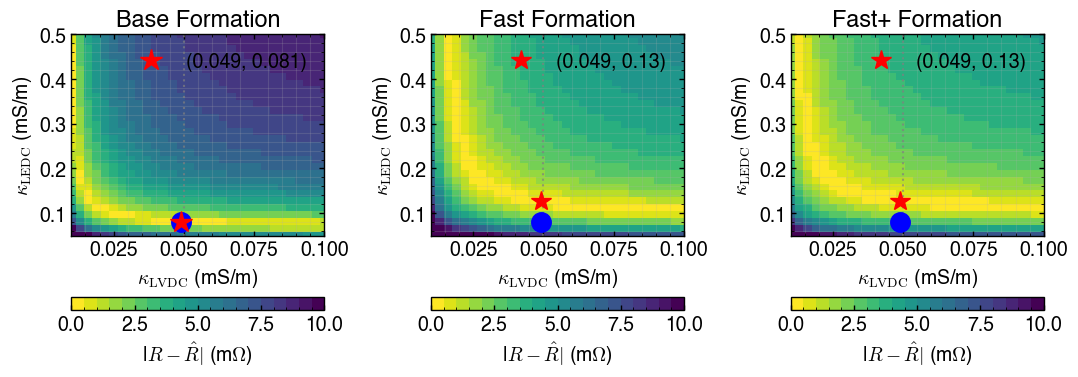

In [79]:
import pickle
%autoreload 2

%matplotlib inline
# Load the pickled simulation results
# with open('outputs/simulation_results.pkl', 'rb') as f:
with open('outputs/resistance_optimization_results_20251202.pkl', 'rb') as f:
    sim_results = pickle.load(f)

nn = 30
kappa_ec_vec = np.linspace(5e-5, 5e-4, nn)
kappa_vc_vec = np.linspace(1e-5, 1e-4, nn+1)

# Extract variables from the loaded results
er1_mat = sim_results['rmse1_e_mat']*1e3
er2_mat = sim_results['rmse2_e_mat']*1e3
er3_mat = sim_results['rmse3_e_mat']*1e3

simutils.plot_heatmaps_kappa(kappa_ec_vec*1e3, kappa_vc_vec*1e3, er1_mat, er2_mat, er3_mat, 
                                   r'|$R - \hat{R}|$ (m$\Omega$)', zmin=0.000, zmax=10, tosave=True,  
                                   savename='outputs/figures/heatmap_resistance_error.svg')